### **Evaluation of symbolic music generation metrics<br>** *Bonus: Optimization phase*
**Author:** Fabian Lohmann (student ID: 852760749)<br>
**Course:** Generative Artificial Intelligence (IM1412), Open University of the Netherlands<br>
*August 2026*

This notebook trains the model again but with several optimizations applied:
- Reworked EOS padding
- Adjusted hyperparameters, more epochs, adjusted dropout, decay, scheduler option. 
- Context window increased from 4 to 16 bars. Stride changed from 50% to 25%.
- Random transpositions for extra training data
- Voice crossing and parallel fifths metrics are integrated into the training
- Now generates 200 chorales for more accurate evaluation

The notebook produces two files:
- `Bach_model_V2.pt`: model weights at best validation loss
- `gen_chorales_V2.json`: 200 chorales generated with the model

**Dataset:** JSB-Chorales (229 training / 76 validation / 77 test chorales)<br>
**Source:** https://github.com/czhuang/JSB-Chorales-dataset

Boulanger-Lewandowski, N., Vincent, P., & Bengio, Y. (2012). Modeling Temporal Dependencies in High-Dimensional Sequences: Application to Polyphonic Music Generation and Transcription. *Proceedings of the 29th International Conference on Machine Learning (ICML-12)*, 1159–1166.

**Disclaimer:** This code was written with the assistance of Claude AI. All code was rewritten, annotated, verified and fully understood by the author.

#### 1. Dependencies and dataset initialization

In [ ]:
import pickle, random, json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# Set hyperparameters
SEED = 1427
SEQ_LEN = 1024              # Context window of 1024 equals 16 bars.
BATCH_SIZE = 16             # Optimized for 4GB VRAM
D_MODEL = 192
NHEAD = 4                   
NUM_LAYERS = 4          
DIM_FF = 768            
DROPOUT = 0.2     
LEARNING_RATE = 3e-4
DECAY = 0.1
EPOCHS = 400
GEN_LENGTH = 1600           # 1600 tokens ≈ 400 timesteps ≈ 25 bars of generated music

USE_TRANSPOSITION = True    # Randomly transpose each chunk of the training chorales to augment the training data
USE_SCHEDULER = False       # Learning rate scheduler
USE_RULE_LOSS = False       # Add voice-crossing and parallel-fifths penalties to the loss
LAMBDA_CROSS = 0.2          # Weight of the voice-crossing penalty
LAMBDA_PAR = 0.2            # Weight of the parallel fifths/octaves penalty

# Initialize random seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Initialize torch device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Torch device: {device}')

# Load the JSB-Chorales database
with open('jsb-chorales-16th.pkl', 'rb') as p:
    data = pickle.load(p, encoding='latin1')
    
print(f'JSB-Chorales dataset loaded:')
print(f'{len(data["train"])} training, {len(data["test"])} test, {len(data["valid"])} validation chorales.')

Torch device: cuda
JSB-Chorales dataset loaded:
229 training, 77 test, 76 validation chorales.


#### 2. Tokenization
In each piece, every timestep is subdivided into four vocal parts: Soprano, Alto, Tenor, Bass (SATB). These are placed sequentially in the token list. Every timestep therefore takes up four positions.

Across all pieces 46 pitches are used (MIDI 36 to 81). These are assigned to tokens 1 to 46. Token 0 is assigned to rests, and tokens 47 and 48 to sequence boundaries. A padding token is added to keep all chunks the same length.

In [2]:
# Define tokens 0 to 49
REST = 0                            # Voice is silent at this timestep
PITCH_MIN, PITCH_MAX = 36, 81       # There are 46 distinct pitches (MIDI 36-81)
BOS, EOS = 47, 48                   # Beginning of sequence, end of sequence
PAD = 49                            # Padding token
VOCAB_SIZE = 50                     # Total number of tokens

# Convert MIDI pitch number to corresponding token value and vice versa
def pitch_to_tok(p):
    return p - PITCH_MIN + 1
def tok_to_pitch(t):
    return None if t == REST else t + PITCH_MIN - 1

# Flatten a chorale into a sequence of tokens
def encode(chorale):
    
    # Create token sequence starting with the BOS token to indicate the start of the sequence
    toks = [BOS]
    
    # For each timestep tuple, assign all pitch tokens to the token sequence
    for timestep in chorale:
        
        # In each timestep tuple, any empty voice values are turned into "None"
        voices = list(timestep) + [None] * (4 - len(timestep))

        # Convert MIDI pitch values in voices to token sequence values, empty voice values are assigned token 0 (REST)
        for p in voices:
            if p is not None:
                toks.append(pitch_to_tok(int(p)))
            else:
                toks.append(REST)
        
    # Add the end of sequence token and return token sequence
    return toks + [EOS]     

# Convert a token sequence into a chorale
def decode(toks):
    body = [t for t in toks if t not in (BOS, EOS)]     # Remove sequence boundary markers
    body = body[:len(body) - len(body) % 4]             # Make sure the token sequence is divisible by four
    
    # Convert back into MIDI pitches and group every timestep into a tuple
    chorale = []
    for i in range(0, len(body), 4):
        timestep = tuple(tok_to_pitch(t) for t in body[i:i+4])
        chorale.append(timestep)
    return chorale

# Verify that the code is working correctly by testing an encode-decode with the first training chorale
test_chorale = [tuple(int(p) for p in timestep) for timestep in data['train'][0]]
assert all(a == b for a, b in zip(test_chorale, decode(encode(test_chorale)))), 'Encode-decode round-trip test failed.'
print('Encode-decode round-trip test successful.')

Encode-decode round-trip test successful.


#### 3. Prepare training data
Prepares for next-token prediction by dividing the chorales into chunks to set up the sliding window and sets up batches of input/target pair chunks.

In [3]:
# Divide a chorale into sliding window training chunks with SEQ_LEN + 1 positions to create SEQ_LEN training pairs
# Training stride is a quarter of the windows, so chunks overlap 25%
def make_chunks(sequences, stride):
    chunks = []
    for seq in sequences:
        
        # Chorales shorter than one window are padded instead of dropped, so short pieces still contribute
        if len(seq) < SEQ_LEN + 1:
            chunks.append(seq + [PAD] * (SEQ_LEN + 1 - len(seq)))
            continue
        
        # Slides the window across the chorale
        for i in range(0, len(seq) - SEQ_LEN, stride):
            chunks.append(seq[i : i + SEQ_LEN + 1])

        # Include the final chunk at a random position so EOS and cadences appear in training without positional bias   
        # Offset is restricted to mod 4         
        r = 4 * random.randint(0, SEQ_LEN // 8 - 1) + 3             # r in {3, 7, ..., 127}
        chunks.append(seq[-(SEQ_LEN + 1 - r):] + [PAD] * r)
    return chunks

# Creates random transpositions of chunk batches to augment the training data
def transpose_batch(x, y):
    both = torch.cat([x, y], dim=1)
    is_pitch = (both >= 1) & (both <= 46)
 
    lo = torch.where(is_pitch, both, torch.full_like(both, 47)).amin(1)
    hi = torch.where(is_pitch, both, torch.zeros_like(both)).amax(1)
    has_pitch = hi > 0
 
    min_shift = torch.where(has_pitch, 1 - lo, torch.zeros_like(lo))
    max_shift = torch.where(has_pitch, 46 - hi, torch.zeros_like(hi))
 
    span = (max_shift - min_shift + 1).clamp(min=1)
    shift = min_shift + (torch.rand(span.shape, device=x.device) * span).long()
    shift = torch.minimum(torch.maximum(shift, min_shift), max_shift).unsqueeze(1)
 
    return (x + shift * ((x >= 1) & (x <= 46)),
            y + shift * ((y >= 1) & (y <= 46)))

# Encode every training and validation chorale into tokens and divides them into chunks
train_chunks = make_chunks(
    [encode(chorale) for chorale in data['train']], stride=SEQ_LEN // 4)    # Sets training stride of 25%
valid_chunks = make_chunks(
    [encode(chorale) for chorale in data['valid']], stride=SEQ_LEN)         # Validation only works with no overlap

# Convert training and validation data to tensors
train_data = torch.tensor(train_chunks, dtype=torch.long)
valid_data = torch.tensor(valid_chunks, dtype=torch.long)

# Set up next token prediction training and validation input/target pairs
train_x, train_y = train_data[:, :-1], train_data[:, 1:]
valid_x, valid_y = valid_data[:, :-1], valid_data[:, 1:]

# Group chunks into batches to optimize for GPU processing
train_loader = DataLoader(TensorDataset(train_x, train_y), batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(TensorDataset(valid_x, valid_y), batch_size=BATCH_SIZE)

print(f'Training: {len(train_chunks)} examples, {len(train_loader)} batches per epoch')
print(f'Validation: {len(valid_chunks)} examples')

Training: 378 examples, 24 batches per epoch
Validation: 105 examples


#### 4. Model architecture
Decoder-only transformer with causal masking. Hyperparameters were selected following common conventions for small-scale models. 

In [4]:
# Remove internal PyTorch optimization error that is not applicable to this setup
import warnings
warnings.filterwarnings("ignore", message="enable_nested_tensor")

# Set up the transformer
class ChoralTransformer(nn.Module):
    
    # Initialize hyperparameters and set up learnable components
    def __init__(self, vocab_size=VOCAB_SIZE, d_model=D_MODEL, nhead=NHEAD,
                 num_layers=NUM_LAYERS, dim_ff=DIM_FF, dropout=DROPOUT, max_len=SEQ_LEN):
        super().__init__()
        
        # Lookup table for tokens, every token ID gets a multi-dimensional vector
        self.token_emb = nn.Embedding(vocab_size, d_model)
        
        # Lookup table for positional embeddings
        self.pos_emb = nn.Embedding(max_len, d_model)
        
        # Transformer setup
        layer = nn.TransformerEncoderLayer(                                         # One transformer block
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)      # Transformer stack
        
        # Convert output embedding to logits for each token
        self.head = nn.Linear(d_model, vocab_size)

    # Forward loop
    def forward(self, x):
        
        # Identify batch size B and sequence length T from input
        B, T = x.shape
        
        # Create position indices
        pos = torch.arange(T, device=x.device).unsqueeze(0)
        
        # Add token embeddings and positional embeddings
        x = self.token_emb(x) + self.pos_emb(pos)
        
        # Create masked matrix where tokens can only attend to past positions 
        mask = nn.Transformer.generate_square_subsequent_mask(T, device=x.device)
        
        # Run input through all transformer layers and output logits
        x = self.transformer(x, mask=mask, is_causal=True)
        return self.head(x)

# Create the model
model = ChoralTransformer().to(device)

print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 1,995,314


Create masks for the metric-based training... 

In [5]:
IDS = torch.arange(VOCAB_SIZE, device=device)
IS_PITCH = (IDS >= 1) & (IDS <= 46)
 
 # Boolean masks [B, T, VOCAB_SIZE] of tokens that would break each rule
def forbidden_masks(x, y):
    B, T = y.shape
    K = T // 4
 
    # Voice crossing
    # The voice directly above the one being predicted is the preceding token, x[:, t]
    # The soprano (role 0) has no voice above it and is left unconstrained
    role = torch.arange(T, device=y.device) % 4
    above = x
    active = (above >= 1) & (above <= 46) & (role >= 1)
    cross = active.unsqueeze(-1) & IS_PITCH & (IDS > above.unsqueeze(-1))
 
    # Parallel fifths / octaves
    # Targets reshaped into an SATB grid: G[b, k, v] is voice v of timestep k
    G = y.view(B, K, 4)
    prev, cur = G[:, :-1, :], G[:, 1:, :]
 
    par = torch.zeros(B, K, 4, VOCAB_SIZE, dtype=torch.bool, device=y.device)
    for v in range(1, 4):                       # voice being predicted
        for u in range(v):                      # higher voices, already fixed this timestep
            pu, pv, cu = prev[:, :, u], prev[:, :, v], cur[:, :, u]
 
            interval = (pu - pv).abs() % 12
            ok = ((pu >= 1) & (pu <= 46) & (pv >= 1) & (pv <= 46) & (cu >= 1) & (cu <= 46)
                  & (cu != pu)                                      # higher voice must move
                  & ((interval == 0) | (interval == 7)))            # octave/unison or fifth
 
            # Candidates preserving the interval, excluding the note this voice already holds
            cand = (((cu.unsqueeze(-1) - IDS).abs() % 12 == interval.unsqueeze(-1))
                    & IS_PITCH & (IDS != pv.unsqueeze(-1)))
            
            # Make sure the mask can't penalize contrary motion, not used because eval notebook doesn't do this either
            # same_direction = (
            #     (cu - pu).unsqueeze(-1) * (IDS - pv.unsqueeze(-1))
            # ) > 0
            # cand = cand & same_direction
            
            par[:, 1:, v, :] |= ok.unsqueeze(-1) & cand
 
    par = par.view(B, T, VOCAB_SIZE)
 
    # Only constrain positions whose target is a pitch or a rest
    valid = ((y >= 0) & (y <= 46)).unsqueeze(-1)
    return cross & valid, par & valid
 
# Penalise probability mass placed on rule-breaking tokens
# Returns the two loss terms and the mean forbidden mass, which is a
# differentiable estimate of the violation rate under the model
def rule_penalties(logits, y, cross_mask, par_mask):
    keep = (y != PAD)
    if not keep.any():
        z = logits.sum() * 0.0
        return z, z, 0.0, 0.0
 
    probs = torch.softmax(logits, dim=-1)
    p_cross = (probs * cross_mask).sum(-1)[keep]
    p_par = (probs * par_mask).sum(-1)[keep]
 
    # -log(1 - p): zero when no mass sits on forbidden tokens, rising steeply as
    # the model commits more of its distribution to them
    aux_cross = -torch.log1p(-p_cross.clamp(max=0.99)).mean()
    aux_par = -torch.log1p(-p_par.clamp(max=0.99)).mean()
    return aux_cross, aux_par, p_cross.mean().item(), p_par.mean().item()

# Check if the masks are working correctly...
def check_masks(n=64):
    xb, yb = train_x[:n].to(device), train_y[:n].to(device)
    B, T = yb.shape
    G = yb.view(B, T // 4, 4)
 
    full = ((G >= 1) & (G <= 46)).all(-1)
    ordered = ((G[:, :, 0] >= G[:, :, 1]) & (G[:, :, 1] >= G[:, :, 2]) & (G[:, :, 2] >= G[:, :, 3]))
    print(f'SATB order holds on {ordered[full].float().mean():.3f} of full timesteps '
          f'(~0.98 is expected if the chunks are aligned)')
 
    cross_mask, par_mask = forbidden_masks(xb, yb)
    keep = (yb != PAD)
    hit_c = cross_mask.gather(-1, yb.unsqueeze(-1)).squeeze(-1)[keep]
    hit_p = par_mask.gather(-1, yb.unsqueeze(-1)).squeeze(-1)[keep]
    print(f'Bach breaks the crossing rule at {hit_c.float().mean():.4f} of positions')
    print(f'Bach breaks the parallel rule at {hit_p.float().mean():.4f} of positions')
 
check_masks()

SATB order holds on 0.972 of full timesteps (~0.98 is expected if the chunks are aligned)
Bach breaks the crossing rule at 0.0070 of positions
Bach breaks the parallel rule at 0.0005 of positions


#### 5. Training loop
The model is trained with AdamW optimizer using cross-entropy loss. 

The checkpoint at best validation loss is saved to `Bach_model_V2.pt`.

In [6]:
# Set AdamW optimizer, which adds weight decay to prevent overfitting
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=DECAY)

# Set up LR scheduler
if USE_SCHEDULER:
    total_steps = EPOCHS * len(train_loader)            # Calculate number of training steps
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=LEARNING_RATE,
        total_steps=total_steps,
        pct_start=200 / total_steps,
        final_div_factor=10
    )

# Set up lists for loss and variable to track the best loss
train_losses, valid_losses = [], []
val_cross_rates, val_par_rates = [], []         # expected metric violation rates, validation set
best_val_loss = float('inf')                    # Starts at infinity so any initial loss will be recorded as improvement
 
 
# Run through all epochs to train the model
for epoch in range(EPOCHS):
 
    # Training mode
    model.train()
    ce_total = 0        # Keeps track of cross-entropy loss
 
    # Training loop
    for x, y in train_loader:                       # Loops through all batches
        x, y = x.to(device), y.to(device)           # Move input to device
 
        # Randomly transpose chunks to augment the training data, in batches to make it go faster
        if USE_TRANSPOSITION:  
            x, y = transpose_batch(x, y)

        # Calculate loss
        logits = model(x)
        ce = nn.functional.cross_entropy(
            logits.view(-1, VOCAB_SIZE), y.view(-1), ignore_index=PAD)
        loss = ce

        # Add auxiliary metric loss, if used
        if USE_RULE_LOSS:
            with torch.no_grad():
                cross_mask, par_mask = forbidden_masks(x, y)
            aux_cross, aux_par, _, _ = rule_penalties(logits, y, cross_mask, par_mask)
            loss = loss + LAMBDA_CROSS * aux_cross + LAMBDA_PAR * aux_par
 
        optimizer.zero_grad()                                   # Clear previous gradients
        loss.backward()                                         # Backpropagation
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)       # Prevent exploding gradients
        optimizer.step()                                        # Update weights
        if USE_SCHEDULER:
            scheduler.step()                                    # Update scheduler
        ce_total += ce.item()                                   # Add to total loss
 
    train_losses.append(ce_total / len(train_loader))           # Average cross-entropy loss this epoch


    # Evaluation
    model.eval()                        # Turn off dropout
    total = pc_total = pp_total = 0     # Reset total loss
    with torch.no_grad():               # Turn off gradient tracking to save memory
        for x, y in valid_loader:       # Loops through all batches to get validation loss and metric rule violations
            x, y = x.to(device), y.to(device)
            logits = model(x)
            total += nn.functional.cross_entropy(
                logits.view(-1, VOCAB_SIZE), y.view(-1), ignore_index=PAD).item()
            cross_mask, par_mask = forbidden_masks(x, y)
            _, _, p_c, p_p = rule_penalties(logits, y, cross_mask, par_mask)
            pc_total += p_c
            pp_total += p_p

    valid_losses.append(total / len(valid_loader))
    val_cross_rates.append(pc_total / len(valid_loader))
    val_par_rates.append(pp_total / len(valid_loader))

    # Check if this epoch's validation loss is the best so far and save the model if true
    if valid_losses[-1] < best_val_loss:
        best_val_loss = valid_losses[-1]
        torch.save(model.state_dict(), 'Bach_model_V2.pt')
 
    # Every 10 epochs show loss data
    if epoch % 10 == 0:
        print(f'Epoch {epoch:>3d} | Train: {train_losses[-1]:.4f} | Valid: {valid_losses[-1]:.4f} '
              f'| Best: {best_val_loss:.4f} | p(cross): {val_cross_rates[-1]:.4f} '
              f'| p(par): {val_par_rates[-1]:.4f}')
 
print(f'\nDone. Best validation loss: {best_val_loss:.4f}')

# Keep the curves for the comparison figures
with open('training_log_V2.json', 'w') as f:
    json.dump({'train_loss': train_losses, 'valid_loss': valid_losses,
               'val_cross_rate': val_cross_rates, 'val_par_rate': val_par_rates,
               'use_transposition': USE_TRANSPOSITION, 'use_scheduler': USE_SCHEDULER,
               'use_rule_loss': USE_RULE_LOSS,
               'lambda_cross': LAMBDA_CROSS, 'lambda_par': LAMBDA_PAR}, f)

Epoch   0 | Train: 3.4618 | Valid: 2.7488 | Best: 2.7488 | p(cross): 0.1193 | p(par): 0.0086
Epoch  10 | Train: 2.0204 | Valid: 1.8966 | Best: 1.8966 | p(cross): 0.0097 | p(par): 0.0089
Epoch  20 | Train: 1.4906 | Valid: 1.2478 | Best: 1.2478 | p(cross): 0.0056 | p(par): 0.0077
Epoch  30 | Train: 1.1468 | Valid: 0.9502 | Best: 0.9502 | p(cross): 0.0075 | p(par): 0.0068
Epoch  40 | Train: 0.9775 | Valid: 0.8212 | Best: 0.8212 | p(cross): 0.0080 | p(par): 0.0064
Epoch  50 | Train: 0.8672 | Valid: 0.7397 | Best: 0.7397 | p(cross): 0.0086 | p(par): 0.0065
Epoch  60 | Train: 0.8008 | Valid: 0.6896 | Best: 0.6896 | p(cross): 0.0081 | p(par): 0.0066
Epoch  70 | Train: 0.7500 | Valid: 0.6581 | Best: 0.6581 | p(cross): 0.0080 | p(par): 0.0066
Epoch  80 | Train: 0.7183 | Valid: 0.6321 | Best: 0.6321 | p(cross): 0.0077 | p(par): 0.0067
Epoch  90 | Train: 0.6939 | Valid: 0.6100 | Best: 0.6100 | p(cross): 0.0079 | p(par): 0.0067
Epoch 100 | Train: 0.6685 | Valid: 0.5936 | Best: 0.5936 | p(cross): 0

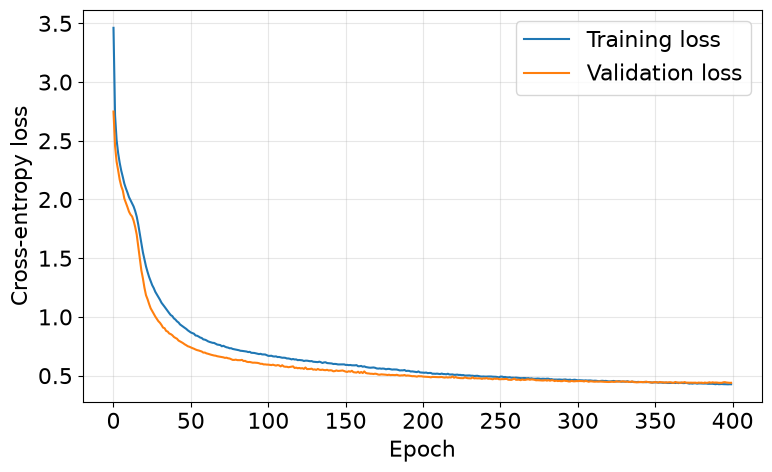

Saved to training_curves_V2.pdf


In [7]:
# Plot the training and validation loss for visualization
plt.rcParams.update({'font.size': 16})
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Training loss')
plt.plot(valid_losses, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/training_curves.pdf', dpi=150)
plt.savefig('figures/training_curves.png', dpi=150)
plt.show()
print('Saved to training_curves_V2.pdf')

#### 6. Generate chorales
Generates 200 chorales. The chorales are generated through autoregressive sampling and are saved to `gen_chorales_V2.json`.

In [8]:
# Load the model and turn off dropout
model.load_state_dict(torch.load('Bach_model_V2.pt'))
model.eval()

# Autoregressive sampling, can generate chorales in batches, but sequential generation (batch=1) may be faster
@torch.no_grad()
def generate_batch(model, n, length=GEN_LENGTH, temperature=1.0, batch=2):
    sequences = []

    for start in range(0, n, batch):
        print(f'Batch {start//batch + 1}/{(n + batch - 1)//batch}')
        B = min(batch, n - start)

        tokens = torch.full((B, 1), BOS, dtype=torch.long, device=device)
        done = torch.zeros(B, dtype=torch.bool, device=device)

        for _ in range(length):
            L = tokens.size(1)

            # Slide the context in steps of 4 so each position keeps its SATB voice role
            s = 0 if L <= SEQ_LEN else 4 * (((L - SEQ_LEN) + 3) // 4)

            logits = model(tokens[:, s:])[:, -1] / temperature
            logits[:, BOS] = float('-inf')
            logits[:, PAD] = float('-inf')
            if (L - 1) % 4 != 0:
                logits[:, EOS] = float('-inf')

            nxt = torch.multinomial(torch.softmax(logits, dim=-1), 1).squeeze(-1)
            nxt = torch.where(done, torch.full_like(nxt, PAD), nxt)
            done |= (nxt == EOS)
            tokens = torch.cat([tokens, nxt.unsqueeze(1)], dim=1)

            if done.all():
                break

        # Cut each row at its first EOS or PAD and drop the leading BOS
        for row in tokens.tolist():
            seq = []
            for t in row[1:]:
                if t in (EOS, PAD):
                    break
                seq.append(t)
            sequences.append(seq)

    return sequences

# Generate 200 chorales in batches of 25 and decode into SATB tuples
torch.manual_seed(SEED)
token_seqs = generate_batch(model, 200)
gen_chorales = [decode(seq) for seq in token_seqs]

# Save to json
with open('gen_chorales_V2.json', 'w') as f:
    json.dump(gen_chorales, f)

# Check how many of the chorales ended with the EOS token
natural = sum(1 for seq in token_seqs if len(seq) < GEN_LENGTH)
print(f'EOS endings: {natural}/{len(gen_chorales)}')
print(f'Saved {len(gen_chorales)} generated chorales to gen_chorales_V2.json')

Batch 1/100
Batch 2/100
Batch 3/100
Batch 4/100
Batch 5/100
Batch 6/100
Batch 7/100
Batch 8/100
Batch 9/100
Batch 10/100
Batch 11/100
Batch 12/100
Batch 13/100
Batch 14/100
Batch 15/100
Batch 16/100
Batch 17/100
Batch 18/100
Batch 19/100
Batch 20/100
Batch 21/100
Batch 22/100
Batch 23/100
Batch 24/100
Batch 25/100
Batch 26/100
Batch 27/100
Batch 28/100
Batch 29/100
Batch 30/100
Batch 31/100
Batch 32/100
Batch 33/100
Batch 34/100
Batch 35/100
Batch 36/100
Batch 37/100
Batch 38/100
Batch 39/100
Batch 40/100
Batch 41/100
Batch 42/100
Batch 43/100
Batch 44/100
Batch 45/100
Batch 46/100
Batch 47/100
Batch 48/100
Batch 49/100
Batch 50/100
Batch 51/100
Batch 52/100
Batch 53/100
Batch 54/100
Batch 55/100
Batch 56/100
Batch 57/100
Batch 58/100
Batch 59/100
Batch 60/100
Batch 61/100
Batch 62/100
Batch 63/100
Batch 64/100
Batch 65/100
Batch 66/100
Batch 67/100
Batch 68/100
Batch 69/100
Batch 70/100
Batch 71/100
Batch 72/100
Batch 73/100
Batch 74/100
Batch 75/100
Batch 76/100
Batch 77/100
Batch 78